# Certified polynomial one-jet reduction benchmarks

This notebook compares interval Jacobians, unreduced polynomial Jacobians, and three sound support-reduction policies. The 100-dimensional target is the saved Poisson PINN checkpoint; running the benchmark never retrains it. Reduced terms are not discarded: their componentwise remainder is propagated rigorously and attached as fresh pointwise residual symbols at the output. Both squared integrations return scalar polynomial zonotopes; intervalization is performed only afterward to obtain the final norm bounds. Tightness is assessed by the actual intervals and the absolute and relative widths of both the final certified $L^2$ and $W^{1,2}$ norm intervals. Before integration, we also report the mean, maximum, and relative mean componentwise widths of the full Jacobian enclosure.

In [1]:
from collections import Counter
from math import sqrt
from pathlib import Path
from time import perf_counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from intervalnets import (IntervalTensor, PZIntegrationCell, affine_tanh_prime_enclosure, enable_interval_eval,
    integrate_pz_onejet_squared, integrate_pz_value_squared,
    load_tanh_mlp_checkpoint)
torch.set_num_threads(1)
torch.set_default_dtype(torch.float64)
enable_interval_eval()
repo_root = Path.cwd()
while not (repo_root / 'notebooks' / 'checkpoints').exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
CHECKPOINT = repo_root / 'notebooks' / 'checkpoints' / 'pinn_100d_poisson.pt'

mkdir -p failed for path /root/.config/matplotlib: [Errno 30] Read-only file system: '/root/.config'
Matplotlib created a temporary cache directory at /tmp/matplotlib-u9ufjtc0 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def make_model(input_dim, hidden=(50, 50, 50), seed=20260731):
    torch.manual_seed(seed)
    layers, previous = [], input_dim
    for width in hidden:
        layers += [torch.nn.Linear(previous, width), torch.nn.Tanh()]
        previous = width
    layers.append(torch.nn.Linear(previous, 1))
    return torch.nn.Sequential(*layers)

def norm_interval(squared):
    return (sqrt(max(0.0, float(squared.lower))), sqrt(max(0.0, float(squared.upper))))

def interval_metrics(bounds, prefix):
    lower, upper = map(float, bounds)
    absolute_width = upper - lower
    scale = max(abs(lower), abs(upper))
    relative_width = absolute_width / scale if scale > 0.0 else 0.0
    return {
        f'{prefix}_lower': lower,
        f'{prefix}_upper': upper,
        f'{prefix}_absolute_width': absolute_width,
        f'{prefix}_relative_width': relative_width,
    }

def jacobian_width_metrics(enclosure):
    lower = torch.as_tensor(enclosure.lower)
    upper = torch.as_tensor(enclosure.upper)
    widths = upper - lower
    scales = torch.maximum(lower.abs(), upper.abs())
    relative_widths = torch.where(scales > 0.0, widths / scales, 0.0)
    return {
        'J_mean_component_width_before_integration': float(widths.mean()),
        'J_max_component_width_before_integration': float(widths.max()),
        'J_relative_mean_component_width_before_integration': float(relative_widths.mean()),
    }

def benchmark(model, box, strategy='topk', **kwargs):
    cell = PZIntegrationCell.from_affine_box(box)
    start = perf_counter()
    traced = model.eval_pz_onejet(cell.domain, return_trace=True,
        reduction_strategy=strategy, **kwargs)
    forward_s = perf_counter() - start
    enclosure = traced.final.J.interval_enclosure()
    jacobian_metrics = jacobian_width_metrics(enclosure)
    start = perf_counter()
    l2_integrated_pz = integrate_pz_value_squared(traced.final.Y, cell, output='pz')
    l2_squared = l2_integrated_pz.interval_enclosure()
    l2_integration_s = perf_counter() - start
    start = perf_counter()
    w12_integrated_pz = integrate_pz_onejet_squared(traced.final, cell, output='pz')
    w12_squared = w12_integrated_pz.interval_enclosure()
    w12_integration_s = perf_counter() - start
    return {
        'strategy': strategy, **kwargs, 'forward_s': forward_s,
        'L2_integration_s': l2_integration_s,
        'W12_integration_s': w12_integration_s,
        'total_s': forward_s + w12_integration_s,
        'J_terms': len(traced.final.J.terms),
        'J_degree': max(map(sum, traced.final.J.terms), default=0),
        'noise': traced.final.J.num_noise,
        'L2_integrated_PZ_terms': len(l2_integrated_pz.terms),
        'W12_integrated_PZ_terms': len(w12_integrated_pz.terms),
        'W12_integrated_PZ_noise': w12_integrated_pz.num_noise,
        **jacobian_metrics,
        **interval_metrics(norm_interval(l2_squared), 'L2'),
        **interval_metrics(norm_interval(w12_squared), 'W12'),
        'trace': traced.records,
    }

## Small-network exact reference
The unreduced path is practical here and provides the polynomial reference endpoint.

In [3]:
small_model = make_model(8, hidden=(10, 10))
small_box = IntervalTensor.from_bounds([-0.15] * 8, [0.15] * 8)
small_exact = benchmark(small_model, small_box, strategy='none', reduce=False)
small_reduced = [benchmark(small_model, small_box, strategy=s, max_terms=24,
    max_degree=2, pca_rank=3, pca_candidates=24) for s in ('topk', 'degree', 'pca')]
small_reference_table = pd.DataFrame([
    {k: v for k, v in row.items() if k != 'trace'}
    for row in [small_exact, *small_reduced]
])
small_reference_table

,strategy,reduce,forward_s,L2_integration_s,W12_integration_s,total_s,J_terms,J_degree,noise,L2_integrated_PZ_terms,W12_integrated_PZ_terms,W12_integrated_PZ_noise,J_mean_component_width_before_integration,J_max_component_width_before_integration,J_relative_mean_component_width_before_integration,L2_lower,L2_upper,L2_absolute_width,L2_relative_width,W12_lower,W12_upper,W12_absolute_width,W12_relative_width,max_terms,max_degree,pca_rank,pca_candidates
0,none,False,0.017318,0.002101,0.035922,0.053240,142,2,36,1,1,29,0.023829,0.033046,0.390604,0.002189,0.002266,0.000077,0.033895,0.002536,0.002775,0.000239,0.086188,NaN,NaN,NaN,NaN
1,topk,NaN,0.009680,0.000781,0.003650,0.013330,24,2,36,1,1,29,0.024067,0.033327,0.393804,0.002189,0.002266,0.000077,0.033895,0.002532,0.002779,0.000247,0.088994,24.0,2.0,3.0,24.0
2,degree,NaN,0.009042,0.000692,0.003957,0.012999,24,2,36,1,1,29,0.024067,0.033327,0.393804,0.002189,0.002266,0.000077,0.033895,0.002532,0.002779,0.000247,0.088994,24.0,2.0,3.0,24.0
3,pca,NaN,0.011844,0.000677,0.004001,0.015845,27,2,39,1,1,32,0.024246,0.033514,0.396248,0.002189,0.002266,0.000077,0.033895,0.002531,0.002780,0.000249,0.089397,24.0,2.0,3.0,24.0


## Saved 100D Poisson PINN: 100–50–50–50–1
The trained candidate is loaded from the committed checkpoint; there is no optimizer or training loop in this notebook. All policies below therefore certify exactly the same saved PINN weights. They preserve a Jacobian polynomial core. The interval result is the speed/looseness baseline. The primary comparison quantities are the absolute and relative widths of both norm intervals; the Jacobian width diagnostics measure tightness before the integration step.

In [4]:
model = load_tanh_mlp_checkpoint(CHECKPOINT)
assert sum(parameter.numel() for parameter in model.parameters()) == 10201
display(pd.DataFrame([{
    'loaded_checkpoint': str(CHECKPOINT.relative_to(repo_root)),
    'training_steps': 0,
}]))
box = IntervalTensor.from_bounds([-0.1] * 100, [0.1] * 100)
configs = [
    ('topk-32', 'topk', dict(max_terms=32)),
    ('topk-64', 'topk', dict(max_terms=64)),
    ('topk-96', 'topk', dict(max_terms=96)),
    ('topk-128', 'topk', dict(max_terms=128)),
    ('topk-192', 'topk', dict(max_terms=192)),
    ('topk-256', 'topk', dict(max_terms=256)),
    ('degree-64', 'degree', dict(max_terms=64, max_degree=2)),
    ('pca-64', 'pca', dict(max_terms=64, pca_rank=4, pca_candidates=32)),
]
rows = []
for label, strategy, kwargs in configs:
    row = benchmark(model, box, strategy=strategy, **kwargs)
    row['label'] = label
    rows.append(row)
start = perf_counter()
interval_bound = model.sobolev_norm(box, p=2.0, order=1, method='interval')
interval_s = perf_counter() - start
interval_l2_bound = model.lpnorm(box, p=2.0, method='interval')
interval_jacobian = model.eval_jacobian(box)
interval_row = {
    'label': 'interval',
    'total_s': interval_s,
    **jacobian_width_metrics(interval_jacobian),
    **interval_metrics((interval_l2_bound.lower, interval_l2_bound.upper), 'L2'),
    **interval_metrics((interval_bound.lower, interval_bound.upper), 'W12'),
}
summary = [{k: v for k, v in row.items() if k != 'trace'} for row in rows]
benchmark_table = pd.DataFrame([interval_row, *summary]).set_index('label')
benchmark_table

                            loaded_checkpoint  training_steps
0  notebooks/checkpoints/pinn_100d_poisson.pt               0


,total_s,J_mean_component_width_before_integration,J_max_component_width_before_integration,J_relative_mean_component_width_before_integration,L2_lower,L2_upper,L2_absolute_width,L2_relative_width,W12_lower,W12_upper,W12_absolute_width,W12_relative_width,strategy,max_terms,forward_s,L2_integration_s,W12_integration_s,J_terms,J_degree,noise,L2_integrated_PZ_terms,W12_integrated_PZ_terms,W12_integrated_PZ_noise,max_degree,pca_rank,pca_candidates
label,,,,,,,,,,,,,,,,,,,,,,,,,,
interval,0.230014,17.548815,20.864813,1.989760,0.0,8.984144e-35,8.984144e-35,1.0,0.0,1.000326e-33,1.000326e-33,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
topk-32,1.218932,17.112410,20.290220,1.981437,0.0,3.013843e-35,3.013843e-35,1.0,0.0,9.760069e-34,9.760069e-34,1.0,topk,32.0,0.534972,0.018786,0.683960,132.0,1.0,350.0,1.0,1.0,251.0,NaN,NaN,NaN
topk-64,1.564244,16.976826,20.127467,1.981290,0.0,3.013843e-35,3.013843e-35,1.0,0.0,9.683504e-34,9.683504e-34,1.0,topk,64.0,0.857276,0.012062,0.706969,164.0,1.0,350.0,1.0,1.0,251.0,NaN,NaN,NaN
topk-96,2.164715,16.849883,19.977130,1.981151,0.0,3.013843e-35,3.013843e-35,1.0,0.0,9.611825e-34,9.611825e-34,1.0,topk,96.0,1.177393,0.012060,0.987322,196.0,1.0,350.0,1.0,1.0,251.0,NaN,NaN,NaN
topk-128,2.378687,16.821834,19.945027,1.981119,0.0,3.013843e-35,3.013843e-35,1.0,0.0,9.595997e-34,9.595997e-34,1.0,topk,128.0,1.380092,0.012665,0.998595,226.0,1.0,350.0,1.0,1.0,251.0,NaN,NaN,NaN
topk-192,2.885157,16.789867,19.907969,1.981084,0.0,3.013843e-35,3.013843e-35,1.0,0.0,9.577961e-34,9.577961e-34,1.0,topk,192.0,1.695162,0.018451,1.189995,278.0,1.0,350.0,1.0,1.0,251.0,NaN,NaN,NaN
topk-256,2.982984,16.765920,19.879198,1.981057,0.0,3.013843e-35,3.013843e-35,1.0,0.0,9.564447e-34,9.564447e-34,1.0,topk,256.0,1.673753,0.032700,1.309231,300.0,1.0,350.0,1.0,1.0,251.0,NaN,NaN,NaN
degree-64,1.495667,16.976826,20.127467,1.981290,0.0,3.013843e-35,3.013843e-35,1.0,0.0,9.683504e-34,9.683504e-34,1.0,degree,64.0,0.876634,0.012276,0.619034,164.0,1.0,350.0,1.0,1.0,251.0,2.0,NaN,NaN
pca-64,1.742541,16.955616,20.104079,1.981267,0.0,3.013843e-35,3.013843e-35,1.0,0.0,9.671521e-34,9.671521e-34,1.0,pca,64.0,1.045065,0.012665,0.697476,168.0,1.0,362.0,1.0,1.0,263.0,NaN,4.0,32.0


In [5]:
assert all(row['total_s'] > 0.0 for row in rows), summary
start = perf_counter()
public_l2_bound = model.pz_l2norm(box)
public_l2_s = perf_counter() - start
start = perf_counter()
public_w12_bound = model.pz_sobolev_norm(box, order=1)
public_w12_s = perf_counter() - start
public_default_table = pd.DataFrame([{
    'public_default_L2_s': public_l2_s,
    'public_default_W12_s': public_w12_s,
    **interval_metrics((public_l2_bound.lower, public_l2_bound.upper), 'public_default_L2'),
    **interval_metrics((public_w12_bound.lower, public_w12_bound.upper), 'public_default_W12'),
}])
public_default_table

,public_default_L2_s,public_default_W12_s,public_default_L2_lower,public_default_L2_upper,public_default_L2_absolute_width,public_default_L2_relative_width,public_default_W12_lower,public_default_W12_upper,public_default_W12_absolute_width,public_default_W12_relative_width
0,0.063594,13.161184,-4.940656e-324,3.013843e-35,3.013843e-35,1.0,-4.940656e-324,9.611825e-34,9.611825e-34,1.0


## Layer diagnostics
The activation rows expose where support generation and certified tail growth occur. The benchmark-level Jacobian widths above are computed after the complete one-jet has been constructed but before either squared integral is evaluated. They use the full enclosure $J_{\mathrm{core}}+[-R,R]$, not merely the reduction remainder. For each entry, the relative width is $(\overline J_{ij}-\underline J_{ij})/\max(|\underline J_{ij}|,|\overline J_{ij}|)$, with exact-zero entries assigned zero; the reported relative mean is the mean of these componentwise ratios.

In [6]:
chosen = next(row for row in rows if row['label'] == 'topk-96')
layer_diagnostics = pd.DataFrame([{
    'module_index': record.layer_index,
    'layer': record.layer_type,
    'seconds': record.elapsed_s,
    'Y_terms': record.summary['Y']['term_count'],
    'J_terms': record.summary['J']['term_count'],
    'J_degree': record.summary['J']['max_degree'],
    'remainder_mean_radius': record.summary['J']['remainder_mean_radius'],
    'remainder_max_radius': record.summary['J']['remainder_max_radius'],
} for record in chosen['trace']])
layer_diagnostics

,module_index,layer,seconds,Y_terms,J_terms,J_degree,remainder_mean_radius,remainder_max_radius
0,-1,Input,0.000000,100,0,0,0.000000,0.000000
1,0,Linear,0.002670,100,0,0,0.000000,0.000000
2,1,Tanh,0.025708,150,96,1,0.026447,0.075139
3,2,Linear,0.009018,150,96,1,0.152948,0.232838
4,3,Tanh,0.486874,200,86,1,0.173841,0.279970
5,4,Linear,0.010750,200,86,1,1.039035,1.504241
6,5,Tanh,0.603452,250,96,1,1.067999,1.518824
7,6,Linear,0.011896,250,96,1,8.423916,9.987156


## Initial activation-approximation errors by neuron

For hidden layer $\ell$ and neuron $i$, the incoming value PZ is intervalized once to obtain the preactivation interval $I_{\ell i}$. That same interval is used for both certified affine enclosures

$$\tanh(z)\in p_{\ell i}^{(0)}z+q_{\ell i}^{(0)}+\delta_{\ell i}^{(0)}[-1,1],$$

$$\tanh'(z)\in p_{\ell i}^{(1)}z+q_{\ell i}^{(1)}+\delta_{\ell i}^{(1)}[-1,1].$$

The tables below show the actual certified approximation-noise coefficients $\delta_{\ell i}^{(0)}$ and $\delta_{\ell i}^{(1)}$ before multiplication by the incoming Jacobian and before Top-$k$/PCA reduction. Rows are one-based hidden-neuron indices; columns are activation layers.

In [7]:
activation_records = [record for record in chosen['trace'] if record.layer_type == 'Tanh']
assert len(activation_records) == 3
assert all(record.summary['tanh_approximation_radii'].numel() == 50 for record in activation_records)

def per_neuron_activation_error_table(summary_key):
    columns = {
        f'hidden_layer_{layer_index}': record.summary[summary_key].detach().cpu().numpy()
        for layer_index, record in enumerate(activation_records, start=1)
    }
    frame = pd.DataFrame(columns)
    frame.index = pd.RangeIndex(1, len(frame) + 1, name='neuron')
    return frame

tanh_value_approximation_errors = per_neuron_activation_error_table(
    'tanh_approximation_radii'
)
tanh_value_approximation_errors

,hidden_layer_1,hidden_layer_2,hidden_layer_3
neuron,,,
1,0.089748,0.080818,0.129496
2,0.062994,0.080196,0.147882
3,0.087721,0.092721,0.094163
4,0.068898,0.073458,0.143326
5,0.076235,0.081105,0.123203
6,0.071089,0.069578,0.129580
7,0.092842,0.082595,0.107198
8,0.078379,0.063086,0.121686
9,0.079325,0.097897,0.160625


### Certified $\tanh'$ approximation errors

In [8]:
tanh_prime_approximation_errors = per_neuron_activation_error_table(
    'tanh_prime_approximation_radii'
)
tanh_prime_approximation_errors

,hidden_layer_1,hidden_layer_2,hidden_layer_3
neuron,,,
1,0.303512,0.288282,0.357791
2,0.253699,0.287270,0.378499
3,0.300122,0.307124,0.310248
4,0.265936,0.274893,0.373685
5,0.279597,0.288077,0.350153
6,0.270216,0.266842,0.357862
7,0.308496,0.291039,0.328011
8,0.283930,0.254079,0.348642
9,0.285594,0.316354,0.390683


### Per-layer approximation-error summary

In [9]:
activation_error_summary = pd.DataFrame([{
    'hidden_layer': layer_index,
    'tanh_delta_min': record.summary['tanh_approximation_radius_min'],
    'tanh_delta_mean': record.summary['tanh_approximation_radius_mean'],
    'tanh_delta_max': record.summary['tanh_approximation_radius_max'],
    'tanh_prime_delta_min': record.summary['tanh_prime_approximation_radius_min'],
    'tanh_prime_delta_mean': record.summary['tanh_prime_approximation_radius_mean'],
    'tanh_prime_delta_max': record.summary['tanh_prime_approximation_radius_max'],
} for layer_index, record in enumerate(activation_records, start=1)]).set_index('hidden_layer')
activation_error_summary

,tanh_delta_min,tanh_delta_mean,tanh_delta_max,tanh_prime_delta_min,tanh_prime_delta_mean,tanh_prime_delta_max
hidden_layer,,,,,,
1,0.052128,0.074179,0.101042,0.229436,0.275129,0.321017
2,0.063086,0.092422,0.128366,0.254079,0.305928,0.356997
3,0.067150,0.133023,0.202250,0.261997,0.359351,0.423880


## Corresponding interval-enclosure radii by neuron

For a direct interval comparison, the same preactivation interval $I_{\ell i}=[l_{\ell i},u_{\ell i}]$ is now mapped through $\tanh$ or $\tanh'$, and the radius (half the interval width) is reported. These are radii of the **entire interval images**, whereas the affine quantities $\delta_{\ell i}^{(0)}$ and $\delta_{\ell i}^{(1)}$ above are only residual radii around dependency-preserving affine functions. Thus the numbers are deliberately related but are not identical error measures.

Since $\tanh$ is increasing, $\tanh(I)=[\tanh(l),\tanh(u)]$. For $\tanh'(z)=1-\tanh^2(z)$, the function increases on $(-\infty,0]$ and decreases on $[0,\infty)$. Hence its maximum is $1$ when $0\in I$; otherwise both extrema are obtained from the endpoints.

In [10]:
def interval_activation_radius_tables(records):
    tanh_columns = {}
    tanh_prime_columns = {}
    for layer_index, record in enumerate(records, start=1):
        lower = record.summary['preactivation_lower']
        upper = record.summary['preactivation_upper']

        preactivation = IntervalTensor.from_bounds(
            lower.detach().cpu().tolist(), upper.detach().cpu().tolist()
        )
        activation = torch.nn.Tanh()
        value_interval = activation.eval(preactivation)
        value_lower = torch.as_tensor(value_interval.lower)
        value_upper = torch.as_tensor(value_interval.upper)
        tanh_columns[f'hidden_layer_{layer_index}'] = (value_upper - value_lower) / 2

        local_jacobian = activation.eval_jacobian(preactivation)
        derivative_lower = torch.diagonal(torch.as_tensor(local_jacobian.lower))
        derivative_upper = torch.diagonal(torch.as_tensor(local_jacobian.upper))
        tanh_prime_columns[f'hidden_layer_{layer_index}'] = (derivative_upper - derivative_lower) / 2

    def frame(columns):
        result = pd.DataFrame({key: value.detach().cpu().numpy() for key, value in columns.items()})
        result.index = pd.RangeIndex(1, len(result) + 1, name='neuron')
        return result

    return frame(tanh_columns), frame(tanh_prime_columns)

tanh_interval_radii, tanh_prime_interval_radii = interval_activation_radius_tables(
    activation_records
)

### Interval radii for $\tanh(I_{\ell i})$

In [11]:
tanh_interval_radii

,hidden_layer_1,hidden_layer_2,hidden_layer_3
neuron,,,
1,0.779130,0.759352,0.846162
2,0.712395,0.757989,0.870088
3,0.774786,0.784138,0.787835
4,0.729328,0.741476,0.864571
5,0.747957,0.759315,0.837111
6,0.735183,0.730712,0.846255
7,0.785498,0.763093,0.810587
8,0.753594,0.712869,0.835183
9,0.755813,0.795434,0.884033


### Interval radii for $\tanh'(I_{\ell i})$

In [12]:
tanh_prime_interval_radii

,hidden_layer_1,hidden_layer_2,hidden_layer_3
neuron,,,
1,0.305871,0.292145,0.367426
2,0.259619,0.288591,0.381770
3,0.303794,0.320469,0.317412
4,0.269782,0.275560,0.378471
5,0.288257,0.299138,0.360464
6,0.274560,0.275883,0.367684
7,0.310544,0.299321,0.344604
8,0.287550,0.256790,0.356245
9,0.289980,0.317674,0.395888


### Layerwise interval-versus-affine comparison

In [13]:
interval_affine_comparison = pd.DataFrame([
    {
        'hidden_layer': layer_index,
        'mean_tanh_interval_radius': tanh_interval_radii[column].mean(),
        'mean_tanh_affine_residual': tanh_value_approximation_errors[column].mean(),
        'mean_tanh_prime_interval_radius': tanh_prime_interval_radii[column].mean(),
        'mean_tanh_prime_affine_residual': tanh_prime_approximation_errors[column].mean(),
    }
    for layer_index, column in enumerate(tanh_interval_radii.columns, start=1)
]).set_index('hidden_layer')
interval_affine_comparison

,mean_tanh_interval_radius,mean_tanh_affine_residual,mean_tanh_prime_interval_radius,mean_tanh_prime_affine_residual
hidden_layer,,,,
1,0.741374,0.074179,0.279481,0.275129
2,0.781755,0.092422,0.312394,0.305928
3,0.847276,0.133023,0.366982,0.359351


## Distribution and geometry of the affine $\tanh'$ residuals

The affine enclosure is deterministic and non-iterative. For $f=\tanh'$ on $[l,u]$, it first takes the secant slope

$$p=\frac{f(u)-f(l)}{u-l}.$$

It then finds every stationary point of the residual $r(x)=f(x)-px$ by solving $f'(x)=p$ analytically. Together with the endpoints, these finite candidates give $r_{\min}$ and $r_{\max}$. Finally,

$$q=\frac{r_{\max}+r_{\min}}2,\qquad \delta=\frac{r_{\max}-r_{\min}}2,$$

so $f(x)\in px+q+\delta[-1,1]$. Apart from a final outward-rounding inflation, this is the minimax vertical shift for the chosen secant slope. The diagnostics below therefore test whether the difficult cases come from isolated bad intervals or from intervals spanning the central bump of $\operatorname{sech}^2$.

In [14]:
derivative_rows = []
for layer_index, record in enumerate(activation_records, start=1):
    lowers = record.summary['preactivation_lower'].detach().cpu().numpy()
    uppers = record.summary['preactivation_upper'].detach().cpu().numpy()
    interval_radii = tanh_prime_interval_radii[f'hidden_layer_{layer_index}'].to_numpy()
    for neuron_index, (lower, upper, interval_radius) in enumerate(
        zip(lowers, uppers, interval_radii), start=1
    ):
        enclosure = affine_tanh_prime_enclosure((float(lower), float(upper)))
        derivative_rows.append({
            'hidden_layer': layer_index,
            'neuron': neuron_index,
            'preactivation_lower': float(lower),
            'preactivation_upper': float(upper),
            'preactivation_width': float(upper - lower),
            'contains_zero': bool(lower <= 0.0 <= upper),
            'affine_slope_p': enclosure.p,
            'affine_intercept_q': enclosure.q,
            'affine_residual_delta': enclosure.delta,
            'interval_radius': float(interval_radius),
            'delta_over_interval_radius': (
                enclosure.delta / float(interval_radius) if interval_radius > 0.0 else 0.0
            ),
        })
tanh_prime_diagnostics = pd.DataFrame(derivative_rows)

distribution_summary = tanh_prime_diagnostics.groupby('hidden_layer').agg(
    delta_min=('affine_residual_delta', 'min'),
    delta_q25=('affine_residual_delta', lambda x: x.quantile(0.25)),
    delta_median=('affine_residual_delta', 'median'),
    delta_q75=('affine_residual_delta', lambda x: x.quantile(0.75)),
    delta_max=('affine_residual_delta', 'max'),
    mean_delta_over_interval_radius=('delta_over_interval_radius', 'mean'),
    zero_crossing_fraction=('contains_zero', 'mean'),
)
distribution_summary

,delta_min,delta_q25,delta_median,delta_q75,delta_max,mean_delta_over_interval_radius,zero_crossing_fraction
hidden_layer,,,,,,,
1,0.229436,0.263440,0.275867,0.286964,0.321017,0.984204,1.0
2,0.254079,0.289682,0.306424,0.322965,0.356997,0.979281,1.0
3,0.261997,0.341602,0.358068,0.377317,0.423880,0.978848,1.0


### Worst derivative residuals and their preactivation intervals

The next table ranks all 150 neuron intervals by $\delta$. It includes the preactivation interval and the ratio between the affine residual and the full interval radius.

In [15]:
worst_tanh_prime_intervals = (
    tanh_prime_diagnostics
    .sort_values('affine_residual_delta', ascending=False)
    .head(15)
    .reset_index(drop=True)
)
worst_tanh_prime_intervals

,hidden_layer,neuron,preactivation_lower,preactivation_upper,preactivation_width,contains_zero,affine_slope_p,affine_intercept_q,affine_residual_delta,interval_radius,delta_over_interval_radius
0,3,32,-1.575940,1.612754,3.188695,True,-0.003234,0.576122,0.423880,0.426487,0.993888
1,3,43,-1.524039,1.523854,3.047893,True,0.000019,0.586511,0.413489,0.413503,0.999965
2,3,50,-1.461363,1.498992,2.960355,True,-0.004293,0.593738,0.406266,0.409482,0.992148
3,3,27,-1.385363,1.463517,2.848880,True,-0.010116,0.603914,0.396112,0.403502,0.981685
4,3,49,-1.422158,1.402718,2.824875,True,0.002584,0.605746,0.394256,0.396093,0.995363
5,3,46,-1.437527,1.380822,2.818349,True,0.007595,0.606564,0.393450,0.398902,0.986333
6,3,9,-1.421050,1.368052,2.789102,True,0.007335,0.609330,0.390683,0.395888,0.986853
7,3,34,-1.416301,1.367477,2.783777,True,0.006797,0.609815,0.390197,0.395005,0.987829
8,3,31,-1.334087,1.413285,2.747372,True,-0.011486,0.613692,0.386341,0.394441,0.979465
9,3,38,-1.356922,1.344892,2.701814,True,0.001835,0.617840,0.382161,0.383405,0.996754


### Residual distributions

The left panel shows the spread of $\delta$ in every layer. The right panel compares $\delta$ with the full interval radius; points near the diagonal retain almost no advantage over the constant interval enclosure.

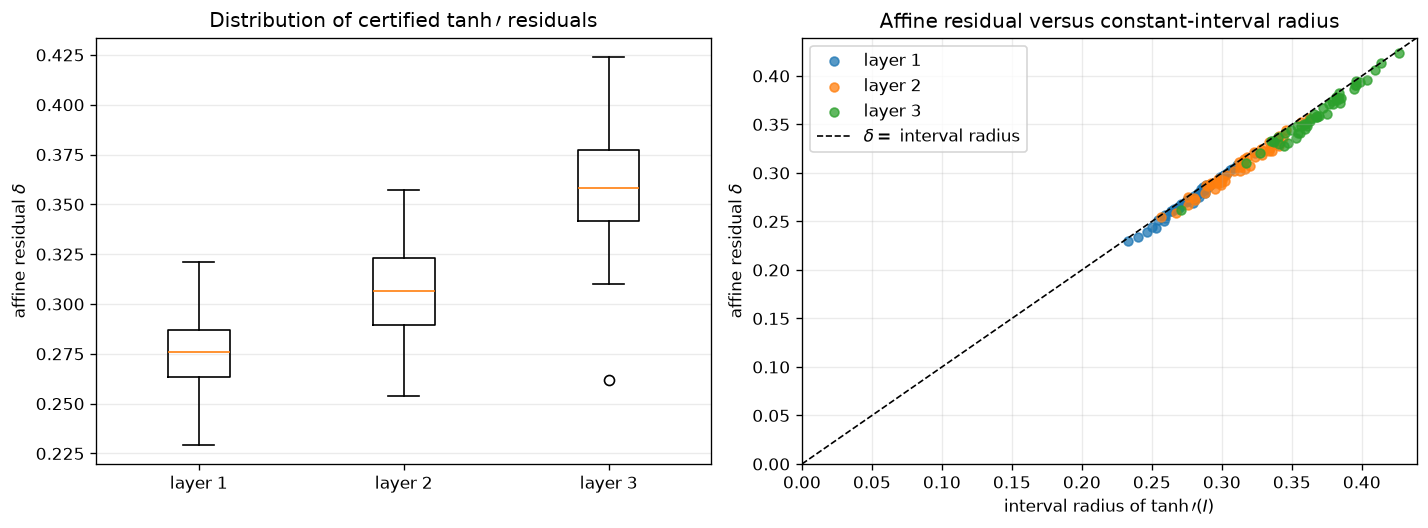

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
layer_groups = [
    group['affine_residual_delta'].to_numpy()
    for _, group in tanh_prime_diagnostics.groupby('hidden_layer')
]
axes[0].boxplot(layer_groups, tick_labels=[f'layer {i}' for i in range(1, 4)])
axes[0].set_ylabel(r'affine residual $\delta$')
axes[0].set_title(r'Distribution of certified $\tanh\prime$ residuals')
axes[0].grid(axis='y', alpha=0.25)

for layer_index, group in tanh_prime_diagnostics.groupby('hidden_layer'):
    axes[1].scatter(
        group['interval_radius'], group['affine_residual_delta'],
        s=28, alpha=0.75, label=f'layer {layer_index}'
    )
limit = 1.03 * tanh_prime_diagnostics['interval_radius'].max()
axes[1].plot([0, limit], [0, limit], '--', color='black', linewidth=1, label=r'$\delta=$ interval radius')
axes[1].set(xlabel=r'interval radius of $\tanh\prime(I)$', ylabel=r'affine residual $\delta$',
            title='Affine residual versus constant-interval radius', xlim=(0, limit), ylim=(0, limit))
axes[1].legend()
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Geometry of the particularly bad affine enclosures

For each hidden layer, the two neurons with the largest $\delta$ are shown. The solid curve is $\tanh'(x)=\operatorname{sech}^2(x)$, the dashed line is $px+q$, and the shaded region is the certified band $px+q\pm\delta$.

,hidden_layer,neuron,preactivation_lower,preactivation_upper,affine_residual_delta,interval_radius,delta_over_interval_radius
0,1,40,-1.112073,1.092490,0.321017,0.323847,0.991262
1,1,7,-1.052830,1.066374,0.308496,0.310544,0.993404
2,2,41,-1.259215,1.218623,0.356997,0.361971,0.986259
3,2,12,-1.206621,1.236036,0.352763,0.356439,0.989687
4,3,32,-1.575940,1.612754,0.423880,0.426487,0.993888
5,3,43,-1.524039,1.523854,0.413489,0.413503,0.999965


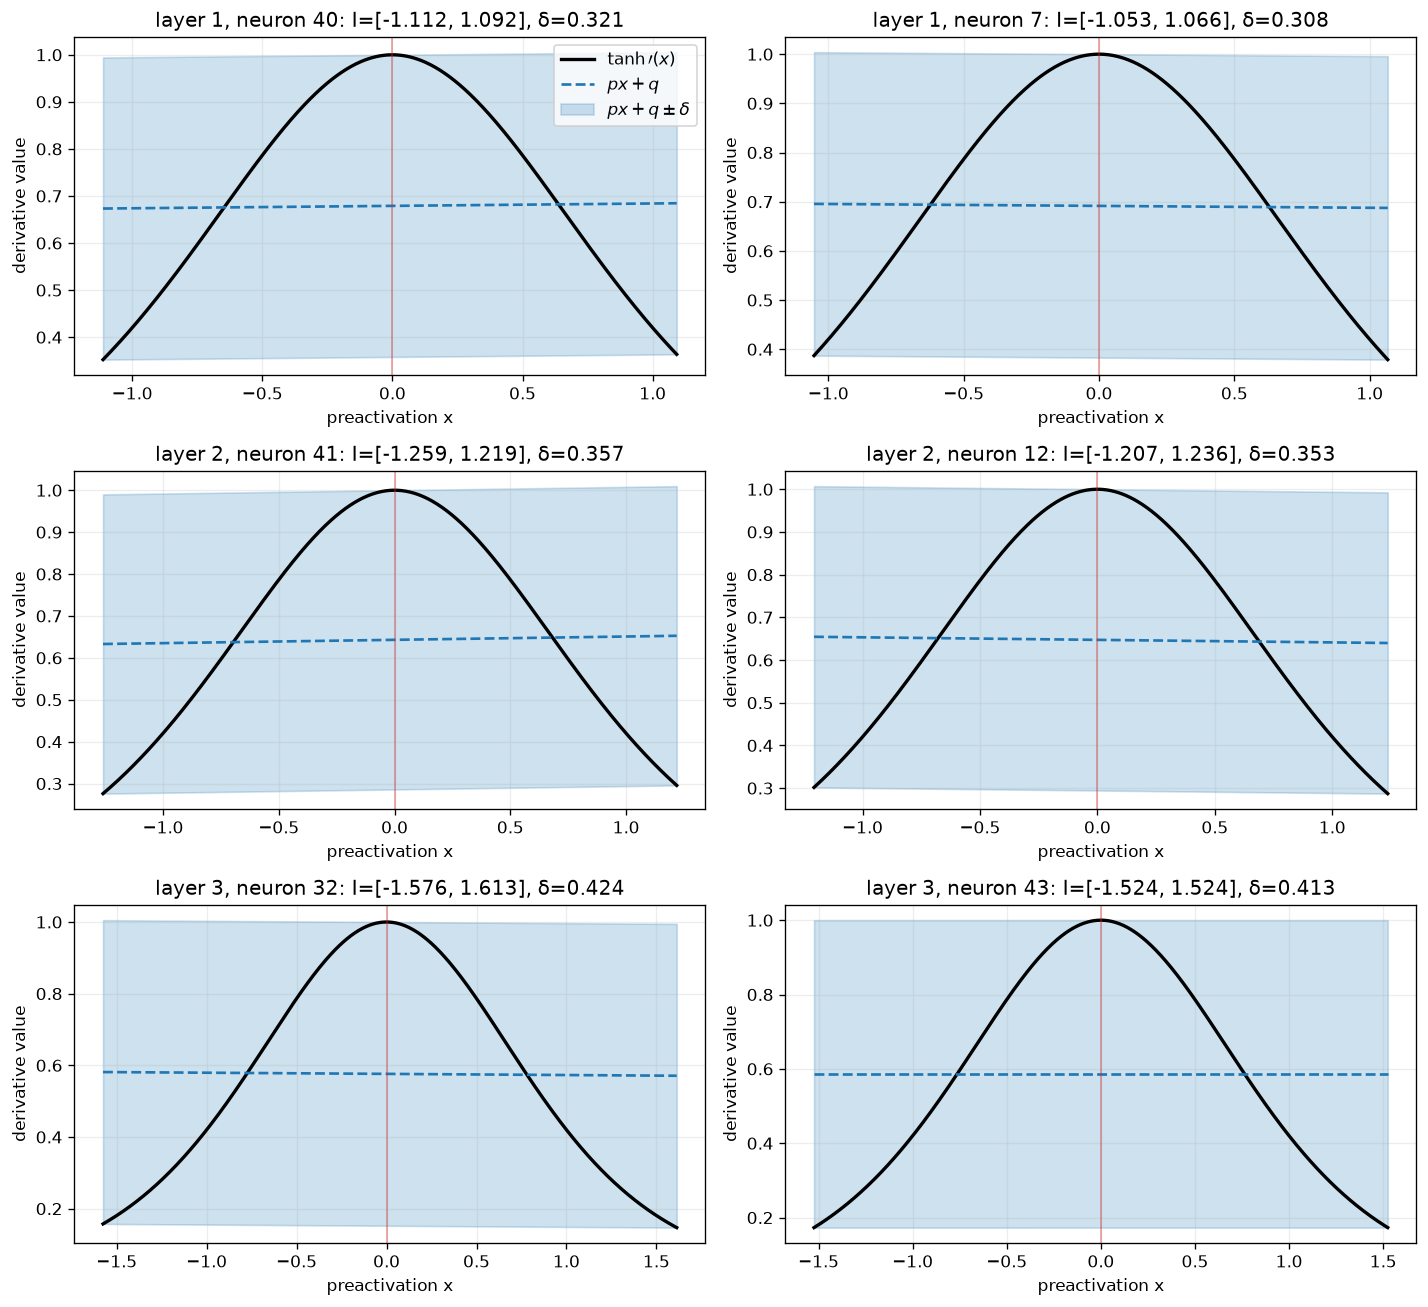

In [17]:
worst_per_layer = (
    tanh_prime_diagnostics
    .sort_values(['hidden_layer', 'affine_residual_delta'], ascending=[True, False])
    .groupby('hidden_layer', group_keys=False)
    .head(2)
    .reset_index(drop=True)
)
fig, axes = plt.subplots(3, 2, figsize=(12, 11), squeeze=False)
for axis, (_, row) in zip(axes.flat, worst_per_layer.iterrows()):
    x = np.linspace(row.preactivation_lower, row.preactivation_upper, 600)
    exact = 1.0 - np.tanh(x) ** 2
    affine = row.affine_slope_p * x + row.affine_intercept_q
    axis.plot(x, exact, color='black', linewidth=2, label=r'$\tanh\prime(x)$')
    axis.plot(x, affine, '--', color='tab:blue', linewidth=1.6, label=r'$px+q$')
    axis.fill_between(
        x, affine - row.affine_residual_delta, affine + row.affine_residual_delta,
        color='tab:blue', alpha=0.22, label=r'$px+q\pm\delta$'
    )
    if row.contains_zero:
        axis.axvline(0.0, color='tab:red', alpha=0.45, linewidth=1)
    axis.set_title(
        f'layer {int(row.hidden_layer)}, neuron {int(row.neuron)}: '
        f'I=[{row.preactivation_lower:.3f}, {row.preactivation_upper:.3f}], '
        f'δ={row.affine_residual_delta:.3f}'
    )
    axis.set_xlabel('preactivation x')
    axis.set_ylabel('derivative value')
    axis.grid(alpha=0.22)
axes[0, 0].legend(loc='best')
fig.tight_layout()
plt.show()

worst_per_layer[['hidden_layer', 'neuron', 'preactivation_lower', 'preactivation_upper',
                 'affine_residual_delta', 'interval_radius', 'delta_over_interval_radius']]

## Four-step Dörfler mark-and-refine comparison

This experiment tests whether domain refinement resolves the broad zero-crossing preactivation intervals identified above. Cells are marked by the usual Dörfler criterion with $\theta=0.5$, using the local certified interval width of the integrated squared $W^{1,2}$ contribution.

For each marked 100D cell, the edge is chosen by an exhaustive one-step interval look-ahead: every coordinate is tentatively bisected and the coordinate minimizing the sum of the two child contribution widths is selected. Equivalently, it maximizes

$$g_j=\eta_K-\bigl(\eta_{K_j^-}+\eta_{K_j^+}\bigr).$$

The resulting partition is shared by interval arithmetic, Top-96, and PCA-64. Thus all three methods certify exactly the same cells. The table reports certification time separately from the shared edge-selection overhead.


In [ ]:
from intervalnets import Interval
from intervalnets.pytorch import (
    _dorfler_marking, _lookahead_sobolev_split_dimension,
    _weighted_sobolev_squared_contribution,
)
from intervalnets.pz_integration import (
    _evaluate_squared_contribution_cache, _independent_pz_sum,
)

REFINEMENT_STEPS = 4
DORFLER_THETA = 0.5
DOMAIN_VOLUME = 0.2 ** 100
PZ_REFINEMENT_CONFIGS = {
    'topk-96': dict(reduction_strategy='topk', max_terms=96),
    'pca-64': dict(
        reduction_strategy='pca', max_terms=64, pca_rank=4, pca_candidates=32
    ),
}

def add_intervals(intervals):
    total = Interval.point(0.0)
    for item in intervals:
        total = total + item
    return total

def normalized_norm_metrics(squared):
    lower = sqrt(max(0.0, float(squared.lower) / DOMAIN_VOLUME))
    upper = sqrt(max(0.0, float(squared.upper) / DOMAIN_VOLUME))
    width = upper - lower
    return lower, upper, width, width / max(abs(lower), abs(upper)) if upper else 0.0

interval_start = perf_counter()
interval_cells = [{
    'box': box,
    'contribution': _weighted_sobolev_squared_contribution(model, box),
}]
interval_certification_s = perf_counter() - interval_start

pz_cells = {}
pz_certification_s = {}
for label, config in PZ_REFINEMENT_CONFIGS.items():
    start = perf_counter()
    pz_cells[label] = [_evaluate_squared_contribution_cache(
        model, box, integrand_kind='w12', **config
    )]
    pz_certification_s[label] = perf_counter() - start

adaptive_rows = []
edge_rows = []
selector_s = 0.0
for refinement_step in range(REFINEMENT_STEPS + 1):
    interval_squared = add_intervals([cell['contribution'] for cell in interval_cells])
    metrics = normalized_norm_metrics(interval_squared)
    adaptive_rows.append({
        'method': 'interval', 'refinement_step': refinement_step,
        'cells': len(interval_cells), 'marked_cells': None,
        'normalized_lower': metrics[0], 'normalized_upper': metrics[1],
        'normalized_absolute_width': metrics[2], 'relative_width': metrics[3],
        'certification_s': interval_certification_s,
        'shared_selector_s': selector_s,
        'end_to_end_s': interval_certification_s + selector_s,
    })
    for label, cells in pz_cells.items():
        squared_pz = _independent_pz_sum([cell.integrated_pz for cell in cells])
        metrics = normalized_norm_metrics(squared_pz.interval_enclosure())
        adaptive_rows.append({
            'method': label, 'refinement_step': refinement_step,
            'cells': len(cells), 'marked_cells': None,
            'normalized_lower': metrics[0], 'normalized_upper': metrics[1],
            'normalized_absolute_width': metrics[2], 'relative_width': metrics[3],
            'certification_s': pz_certification_s[label],
            'shared_selector_s': selector_s,
            'end_to_end_s': pz_certification_s[label] + selector_s,
        })
    if refinement_step == REFINEMENT_STEPS:
        break

    indicators = [
        float(cell['contribution'].upper) - float(cell['contribution'].lower)
        for cell in interval_cells
    ]
    marked = set(_dorfler_marking(indicators, DORFLER_THETA))
    for row in adaptive_rows[-len(PZ_REFINEMENT_CONFIGS) - 1:]:
        row['marked_cells'] = len(marked)

    selected = {}
    for cell_index in sorted(marked):
        start = perf_counter()
        split_dim, children, _, candidates = _lookahead_sobolev_split_dimension(
            model, interval_cells[cell_index]['box']
        )
        selector_s += perf_counter() - start
        selected[cell_index] = (split_dim, children)
        for rank, candidate in enumerate(candidates[:5], start=1):
            edge_rows.append({
                'refinement_step': refinement_step + 1,
                'marked_cell': cell_index, 'rank': rank, **candidate,
            })

    new_interval_cells = []
    for cell_index, cell in enumerate(interval_cells):
        if cell_index not in marked:
            new_interval_cells.append(cell)
            continue
        _, children = selected[cell_index]
        for child in children:
            start = perf_counter()
            contribution = _weighted_sobolev_squared_contribution(model, child)
            interval_certification_s += perf_counter() - start
            new_interval_cells.append({'box': child, 'contribution': contribution})
    interval_cells = new_interval_cells

    for label, config in PZ_REFINEMENT_CONFIGS.items():
        new_cells = []
        for cell_index, cell in enumerate(pz_cells[label]):
            if cell_index not in marked:
                new_cells.append(cell)
                continue
            _, children = selected[cell_index]
            for child in children:
                start = perf_counter()
                new_cells.append(_evaluate_squared_contribution_cache(
                    model, child, integrand_kind='w12', **config
                ))
                pz_certification_s[label] += perf_counter() - start
        pz_cells[label] = new_cells

adaptive_refinement_table = pd.DataFrame(adaptive_rows)
edge_choice_table = pd.DataFrame(edge_rows)
adaptive_refinement_table


### Observed four-step result

| Method | Step 0 normalized width | Step 4 normalized width | Reduction | Certification time | Shared selector time |
|---|---:|---:|---:|---:|---:|
| Interval | 88.846805 | 87.815079 | 1.16% | 1.95 s | 191.04 s |
| Top-96 | 85.370153 | 84.143588 | 1.44% | 21.93 s | 191.04 s |
| PCA-64 | 85.900362 | 84.720192 | 1.37% | 19.31 s | 191.04 s |

The four selected coordinate directions were 70, 34, 58, and 49 (zero-based); coordinate 49 was selected independently in both marked cells in the fourth round. The local look-ahead gains are only about 0.84%--0.98% of the marked-cell indicator per bisection. Four refinements therefore improve all methods only mildly and do not remove the derivative-enclosure bottleneck. The exhaustive selector is intentionally diagnostic: its cost is too high for production use, so a practical implementation should approximate this ranking with a cheaper sensitivity score once the useful coordinate pattern is understood.


### Derivative-approximation errors on the final six cells

This final diagnostic reruns the Top-96 one-jet trace on the six active cells and reports the volume-weighted mean $\tanh'$ residual, the worst residual, and the volume-weighted fraction of neuron intervals still crossing zero.


In [ ]:
refined_activation_rows = []
for cell_index, active in enumerate(interval_cells):
    cell = PZIntegrationCell.from_affine_box(active['box'])
    traced = model.eval_pz_onejet(
        cell.domain, return_trace=True, reduction_strategy='topk', max_terms=96
    )
    activation_trace = [record for record in traced.records if record.layer_type == 'Tanh']
    cell_volume = float(cell.volume)
    for layer_index, record in enumerate(activation_trace, start=1):
        lower = record.summary['preactivation_lower']
        upper = record.summary['preactivation_upper']
        delta = record.summary['tanh_prime_approximation_radii']
        refined_activation_rows.append({
            'cell': cell_index, 'hidden_layer': layer_index,
            'cell_volume': cell_volume,
            'mean_tanh_prime_delta': float(delta.mean()),
            'max_tanh_prime_delta': float(delta.max()),
            'zero_crossing_fraction': float(((lower <= 0) & (upper >= 0)).double().mean()),
        })
refined_activation_cells = pd.DataFrame(refined_activation_rows)
refined_activation_summary = pd.DataFrame([
    {
        'hidden_layer': layer_index,
        'initial_mean_delta': tanh_prime_approximation_errors[f'hidden_layer_{layer_index}'].mean(),
        'refined_volume_weighted_mean_delta': np.average(
            group['mean_tanh_prime_delta'], weights=group['cell_volume']
        ),
        'refined_max_delta': group['max_tanh_prime_delta'].max(),
        'refined_volume_weighted_zero_crossing_fraction': np.average(
            group['zero_crossing_fraction'], weights=group['cell_volume']
        ),
    }
    for layer_index, group in refined_activation_cells.groupby('hidden_layer')
]).set_index('hidden_layer')
refined_activation_summary


| Hidden layer | Initial mean $\delta$ | Refined volume-weighted mean $\delta$ | Refined maximum $\delta$ | Refined zero-crossing fraction |
|---:|---:|---:|---:|---:|
| 1 | 0.275129 | 0.270346 | 0.317705 | 100% |
| 2 | 0.305928 | 0.300190 | 0.353773 | 100% |
| 3 | 0.359351 | 0.352820 | 0.420270 | 100% |

Every neuron interval on every final cell still crosses zero. The four bisections reduce the mean derivative residual by only about 1.7%--1.8%, so the central $\operatorname{sech}^2$ bump remains present everywhere. This directly explains why four refinement rounds improve the final $W^{1,2}$ widths only mildly.


### Edge-choice diagnostics

The table shows the five best coordinate candidates for every marked cell. Coordinate indices are zero-based, matching the network input convention.


In [ ]:
edge_choice_table

### Refinement convergence


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for method, group in adaptive_refinement_table.groupby('method'):
    axes[0].plot(
        group['refinement_step'], group['normalized_absolute_width'],
        marker='o', label=method,
    )
axes[0].set(
    xlabel='refinement step', ylabel=r'normalized $W^{1,2}$ interval width',
    title='Certified-width reduction on the shared partition',
)
axes[0].grid(alpha=0.25); axes[0].legend()

chosen_edges = edge_choice_table[edge_choice_table['rank'] == 1]
edge_counts = chosen_edges['split_dim'].value_counts().sort_index()
axes[1].bar(edge_counts.index.astype(str), edge_counts.values)
axes[1].set(
    xlabel='selected coordinate (zero-based)', ylabel='number of selected bisections',
    title='Coordinates selected by one-step look-ahead',
)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

## No-refinement hybrid quadratic $\tanh'$ experiment

This experiment keeps the original 100D cell and replaces the affine $\tanh'$ enclosure only when the secant slope is flat relative to the derivative interval radius. The quadratic proposal interpolates $\tanh'$ at the lower endpoint, midpoint, and upper endpoint. A fixed 64-bin, non-adaptive Taylor-form pass certifies and recenters its residual band; there is no fitting iteration, optimizer, root search, or domain refinement. A candidate is used only when its certified residual is smaller than the affine residual.

The relative flatness score is $|p|h/r_I$, where $p$ is the affine secant slope, $h=(u-l)/2$, and $r_I$ is the interval radius of $\tanh'([l,u])$. The broad threshold $0.1$ selects all 150 bump-containing intervals; thresholds $0.0025$, $0.005$, $0.01$, and $0.02$ select respectively $(1,2,10,26)$ neurons across all layers. The implementation streams quadratic monomials through Top-$k$/PCA instead of first materializing the full squared PZ. It separately records the approximation residual and the radius caused by reducing the quadratic polynomial core.


In [ ]:
quadratic_configs = [
    ('quadratic-all-topk-96', 'topk', dict(
        max_terms=96, derivative_enclosure='quadratic_flat',
        derivative_flatness_threshold=0.1, quadratic_compression_guard=False,
    )),
    ('quadratic-all-pca-64', 'pca', dict(
        max_terms=64, pca_rank=4, pca_candidates=32,
        derivative_enclosure='quadratic_flat',
        derivative_flatness_threshold=0.1, quadratic_compression_guard=False,
    )),
    ('quadratic-superflat-topk-96', 'topk', dict(
        max_terms=96, derivative_enclosure='quadratic_flat',
        derivative_flatness_threshold=0.0025, quadratic_compression_guard=False,
    )),
    ('quadratic-guarded-topk-96', 'topk', dict(
        max_terms=96, derivative_enclosure='quadratic_flat',
        derivative_flatness_threshold=0.1, quadratic_compression_guard=True,
    )),
]
quadratic_rows = []
quadratic_domain_volume = 0.2 ** 100
quadratic_layer_rows = []
for label, strategy, kwargs in quadratic_configs:
    result = benchmark(model, box, strategy=strategy, **kwargs)
    quadratic_rows.append({
        'method': label, 'total_s': result['total_s'],
        'normalized_W12_width': (
            result['W12_absolute_width'] / sqrt(quadratic_domain_volume)
        ),
        'J_mean_width': result['J_mean_component_width_before_integration'],
        'J_terms': result['J_terms'], 'J_degree': result['J_degree'],
    })
    for layer_index, record in enumerate(
        [item for item in result['trace'] if item.layer_type == 'Tanh'], start=1
    ):
        summary = record.summary
        quadratic_layer_rows.append({
            'method': label, 'hidden_layer': layer_index,
            'quadratic_neurons': summary['tanh_prime_quadratic_count'],
            'mean_selected_delta': summary['tanh_prime_approximation_radius_mean'],
            'mean_affine_delta': float(summary['tanh_prime_affine_radii'].mean()),
            'mean_quadratic_reduction_radius': (
                summary['tanh_prime_polynomial_reduction_radius_mean']
            ),
            'mean_propagated_J_remainder': summary['J']['remainder_mean_radius'],
        })
quadratic_benchmark_table = pd.DataFrame(quadratic_rows).set_index('method')
quadratic_layer_table = pd.DataFrame(quadratic_layer_rows).set_index(
    ['method', 'hidden_layer']
)
display(quadratic_benchmark_table)
quadratic_layer_table


### Observed no-refinement result

| Method | Quadratic neurons by layer | Time | Normalized $W^{1,2}$ width | Mean Jacobian width |
|---|---:|---:|---:|---:|
| Interval | -- | 0.115 s | 88.8468 | 17.5488 |
| Affine Top-96 | $(0,0,0)$ | 2.03 s | 85.3702 | 16.8499 |
| Affine PCA-64 | $(0,0,0)$ | 1.67 s | 85.9004 | 16.9556 |
| Quadratic-all Top-96 | $(50,50,50)$ | 9.75 s | 480.6166 | 95.3806 |
| Quadratic-all PCA-64 | $(50,50,50)$ | 7.59 s | 485.4710 | 96.3479 |
| Quadratic-superflat Top-96 ($0.0025$) | $(0,0,1)$ | 2.30 s | 85.5927 | 16.8942 |
| Compression-guarded Top-96 | $(0,0,0)$ | 2.98 s | 85.3702 | 16.8499 |

The quadratic fit itself succeeds: with all neurons selected, the mean certified local residual falls from $(0.2751,0.3059,0.3594)$ to $(0.0385,0.0520,0.0821)$. The failure occurs when the new degree-two support is reduced. For Top-96, the mean quadratic-core reduction radii are approximately $(0.545,0.613,0.717)$, and the propagated mean Jacobian remainder grows from $(0.0264,0.1738,1.0680)$ to $(0.0560,0.5814,6.0930)$. PCA-64 behaves similarly. Even switching only the single flattest neuron slightly worsens the final width.

The compression guard compares, componentwise, $\delta_2+r_{\mathrm{quad}}$ with the original affine $\delta_1$ and falls back to the affine enclosure unless the retained quadratic plus its certified reduction radius is locally better. At Top-96 it rejects all 150 candidates, reproducing the affine certificate exactly but with diagnostic overhead. Thus the negative result is not that the parabola is inaccurate; it is that the current monomial-wise Top-$k$/PCA representation cannot retain its structured quadratic form economically. A useful next algorithmic step would need grouped or factored quadratic terms rather than merely a larger $k$.


## Interpretation

- Top-k is the cheapest reduction and gives a direct runtime/tightness knob.
- Both squared integrations return scalar PZs. Pointwise uncertainty becomes a fresh integrated global generator; intervalization occurs only after this integration step.
- For both $L^2$ and $W^{1,2}$, the primary final tightness diagnostic is $U-L$ for the certified norm interval $[L,U]$. The reported relative width is $(U-L)/\max(|L|,|U|)$ (and is defined as zero when both endpoints vanish); it is not obtained by dividing by the lower bound.
- The mean, maximum, and relative mean Jacobian component widths are complementary pre-integration diagnostics: they show how much tightness has already been lost in the image enclosure, before squaring and integration can add further overestimation. The relative mean averages the entrywise width divided by the largest endpoint magnitude, so it is scale-normalized and lies between zero and two.
- In the target experiment every method currently has $L=0$ for both norms, hence every relative norm width is $100\%$. Here a smaller upper endpoint happens to equal a smaller absolute width, but it does not constitute an improvement in relative precision.
- The target-network relative mean Jacobian widths are close to two. This says that most component intervals straddle zero and are nearly symmetric relative to their endpoint magnitude. The absolute mean and maximum widths therefore remain the more discriminating Jacobian diagnostics in this experiment.
- The full per-neuron tables separate the initial activation-value error from the derivative error. Across hidden layers 1--3, the mean $\tanh$ radii are approximately $0.0742$, $0.0924$, and $0.1330$, whereas the mean $\tanh'$ radii are approximately $0.2751$, $0.3059$, and $0.3594$. Thus the derivative enclosure is already the larger local error source before Jacobian multiplication and support reduction.
- Comparing with interval arithmetic explains the contrasting norm results. The mean full interval radii for $\tanh(I)$ are approximately $0.7414$, $0.7818$, and $0.8473$, about an order of magnitude larger than the affine value residuals. In contrast, the mean interval radii for $\tanh'(I)$ are $0.2795$, $0.3124$, and $0.3670$, only slightly larger than the affine derivative residuals $0.2751$, $0.3059$, and $0.3594$. The affine value enclosure therefore preserves substantial dependency information, while the affine derivative enclosure is already nearly as uncertain as replacing $\tanh'$ by its interval range. This is the local mechanism behind the strong $L^2$ improvement but weak $W^{1,2}$ improvement.
- The derivative problem is systematic rather than caused by a few outliers. Every one of the 150 preactivation intervals crosses zero, so every interval contains the central maximum of $\tanh'=\operatorname{sech}^2$. The layerwise median residuals are approximately $0.276$, $0.306$, and $0.358$, and the mean ratios $\delta/\operatorname{rad}(\tanh'(I))$ are $98.4\%$, $97.9\%$, and $97.9\%$. The worst case, hidden layer 3 neuron 32 on $[-1.576,1.613]$, has $\delta=0.42388$ versus interval radius $0.42649$. Its nearly zero secant slope makes the affine line essentially constant, so the band must cover almost the entire bump height.
- Four Dörfler rounds on the 100D Poisson cube do not yet change that geometry. The shared look-ahead partition has six cells, but every hidden-neuron preactivation interval on every cell still crosses zero. The volume-weighted mean $\tanh'$ residuals fall only from $(0.2751,0.3059,0.3594)$ to $(0.2703,0.3002,0.3528)$. Consequently Top-96 improves from $85.3702$ to $84.1436$ in normalized $W^{1,2}$ width, while interval arithmetic improves from $88.8468$ to $87.8151$.
- Exhaustive 100-coordinate look-ahead is useful as a diagnostic but not as the production edge selector: it costs about $191$ seconds for four rounds, compared with about $22$ seconds for the Top-96 certifications on the final partition. The selected coordinates and candidate rankings can be used to validate a cheaper sensitivity-based proxy.
- The no-refinement quadratic experiment sharply reduces the local $\tanh'$ approximation residuals, but ordinary monomial-wise reduction loses the gain. Quadratic-all Top-96 increases the normalized $W^{1,2}$ width from $85.3702$ to $480.6166$ because the new quadratic-core reduction radii exceed the old affine residuals. A compression-aware guard rejects every quadratic candidate at Top-96 and exactly recovers the affine result. This points to structured/factored quadratic retention, not a larger unstructured Top-$k$, as the relevant next representation change.
- Degree capping matters once higher-degree terms survive the importance ranking; on narrow boxes it can coincide with top-k.
- PCA is certified because the projected generators are intervalized in PCA coordinates and the orthogonal residual is bounded componentwise. Its SVD and added pointwise generators must earn their cost empirically.
- Extending the target sweep from Top-96 through Top-256 shows clear saturation: Top-256 remains just below three seconds in this run but improves the $W^{1,2}$ width by only about $0.49\%$ relative to Top-96. Top-192 is the more robust sub-three-second accuracy-biased configuration.
- The unreduced polynomial path is intentionally limited to smaller networks: it diagnoses genuine monomial growth rather than hiding it behind interval propagation.